
# Quantum-Based Anomaly Detection in Network Traffic Using Qiskit’s Variational Quantum Classifier

---

## 1. Introduction

This project investigates the use of **quantum-enhanced machine learning** for detecting anomalies in structured network traffic data. We implement and evaluate a **Variational Quantum Classifier (VQC)** using Qiskit, applying it to a synthetic dataset that simulates realistic security-relevant traffic patterns.

Quantum machine learning models are considered for their potential to generalize better on high-dimensional or complex decision boundaries. This project focuses on assessing whether a quantum approach, using standard Qiskit components, can effectively separate **normal** and **anomalous** traffic in a cybersecurity context.

---



## 2. Project Objectives

This SQA project aims to:

- Apply a Qiskit-based Variational Quantum Classifier to a network traffic anomaly detection task
- Use realistic and reproducible synthetic data representing packet-based traffic behavior
- Preprocess data to fit quantum model constraints (e.g., scaling for feature maps)
- Train a hybrid quantum-classical model and evaluate its performance
- Compare results to classical models for benchmarking
- Analyze misclassifications and model behavior in a security context
- Provide a technically structured evaluation aligned with software quality and AI/ML assurance practices



## 3. System Description

The core system is a hybrid quantum-classical anomaly detection pipeline. It consists of:

- A structured input dataset simulating network behavior over time
- A preprocessing module for scaling and encoding features
- A quantum model composed of:
  - `ZZFeatureMap` for quantum encoding of classical input
  - `RealAmplitudes` ansatz as a variational circuit
- The `VQC` model from Qiskit Machine Learning
- Evaluation metrics and benchmarking using classical machine learning models

No internal changes are made to Qiskit’s VQC or underlying quantum components. The project treats Qiskit ML APIs as software black-box components, as expected in software quality evaluations.


## Experimental Parameters

In [1]:
import json
from pathlib import Path

# ----------------------------
# Experiment Parameters
# ----------------------------
params = {
    'run': 10,
    'description': "Max training iterations set to 50",
    'random_seed': 42,
    'n_samples': 1000,
    'anomaly_ratio': 0.5,
    'test_size': 0.3,
    'maxiter': 50,
}

# Dictionary to collect metrics for all models
metrics = {}
metrics['run'] = params['run']
metrics['description'] = params['description']

# OUTPUT Folder Paths
PROJECT_ROOT = Path.cwd()   # assumes notebook is run from project root
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR = PROJECT_ROOT / "results" / f"run{params['run']}"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ----------------------------
# Save parameters to experiments/runX.json
# ----------------------------
run_number = params["run"]
param_file = EXPERIMENTS_DIR / f"parameters_run{run_number}.json"

with open(param_file, "w", encoding="utf-8") as f:
    json.dump(params, f, indent=4)

print(f"Parameters saved to: {param_file}")

Parameters saved to: D:\SQA Projects 2026\SQA-2026-Quantum-Based-Network-Anomaly-Detection-VQC\experiments\parameters_run10.json


In [3]:
# ----------------------------
# Load parameters from a specific run
# ----------------------------
# import json
# from pathlib import Path
#
# run_to_load = 1   # change this to the run number you want
#
# project_root = Path.cwd()   # assumes notebook is run from project root
# experiments_dir = project_root / "experiments"
# param_file = experiments_dir / f"parameters_run{run_to_load}.json"
#
# with open(param_file, "r", encoding="utf-8") as f:
#     params = json.load(f)
#
# print(f"Loaded parameters from: {param_file}")
# print(params)

In [4]:
params["run"]

10

In [5]:
params["description"]

'Max training iterations set to 50'

## 4. Data Design

We simulate structured time-based snapshots of network traffic for classification.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(params['random_seed'])

def generate_network_traffic_data(n_samples=1000, anomaly_ratio=0.5):
    n_anomalous = int(n_samples * anomaly_ratio)
    n_normal = n_samples - n_anomalous

    # Normal traffic
    normal_packets = np.random.normal(loc=100, scale=10, size=n_normal)
    normal_bytes = normal_packets * np.random.normal(loc=10, scale=2, size=n_normal)
    normal_drop_rate = np.random.normal(loc=0.01, scale=0.005, size=n_normal)
    normal_protocol = np.random.choice([1], size=n_normal)  # TCP only

    # Anomalous traffic
    anomaly_packets = np.random.normal(loc=300, scale=40, size=n_anomalous)
    anomaly_bytes = anomaly_packets * np.random.normal(loc=15, scale=5, size=n_anomalous)
    anomaly_drop_rate = np.random.normal(loc=0.1, scale=0.03, size=n_anomalous)
    anomaly_protocol = np.random.choice([2, 3], size=n_anomalous)  # sudden protocol change (e.g., UDP, ICMP)

    # Combine
    X = np.vstack([
        np.column_stack((normal_packets, normal_bytes, normal_drop_rate, normal_protocol)),
        np.column_stack((anomaly_packets, anomaly_bytes, anomaly_drop_rate, anomaly_protocol))
    ])
    y = np.array([0]*n_normal + [1]*n_anomalous)

    return pd.DataFrame(X, columns=["packets_per_sec", "bytes_per_sec", "packet_drop_rate", "protocol_id"]), y

# Generate dataset
X_df, y = generate_network_traffic_data(n_samples=params['n_samples'], anomaly_ratio=params['anomaly_ratio'])

## 5. Preprocessing Pipeline

StandardScaler ensures numerical features are centered and scaled appropriately for use in a quantum circuit.

In [7]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=params['test_size'], stratify=y, random_state=params['random_seed'])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## 6. Exploratory Visualizations and Feature Analysis

We now produce a set of rich visualizations to explore:
- Pairwise feature relationships between classes
- Feature correlation matrix
- PCA transformation for decision boundary visualization


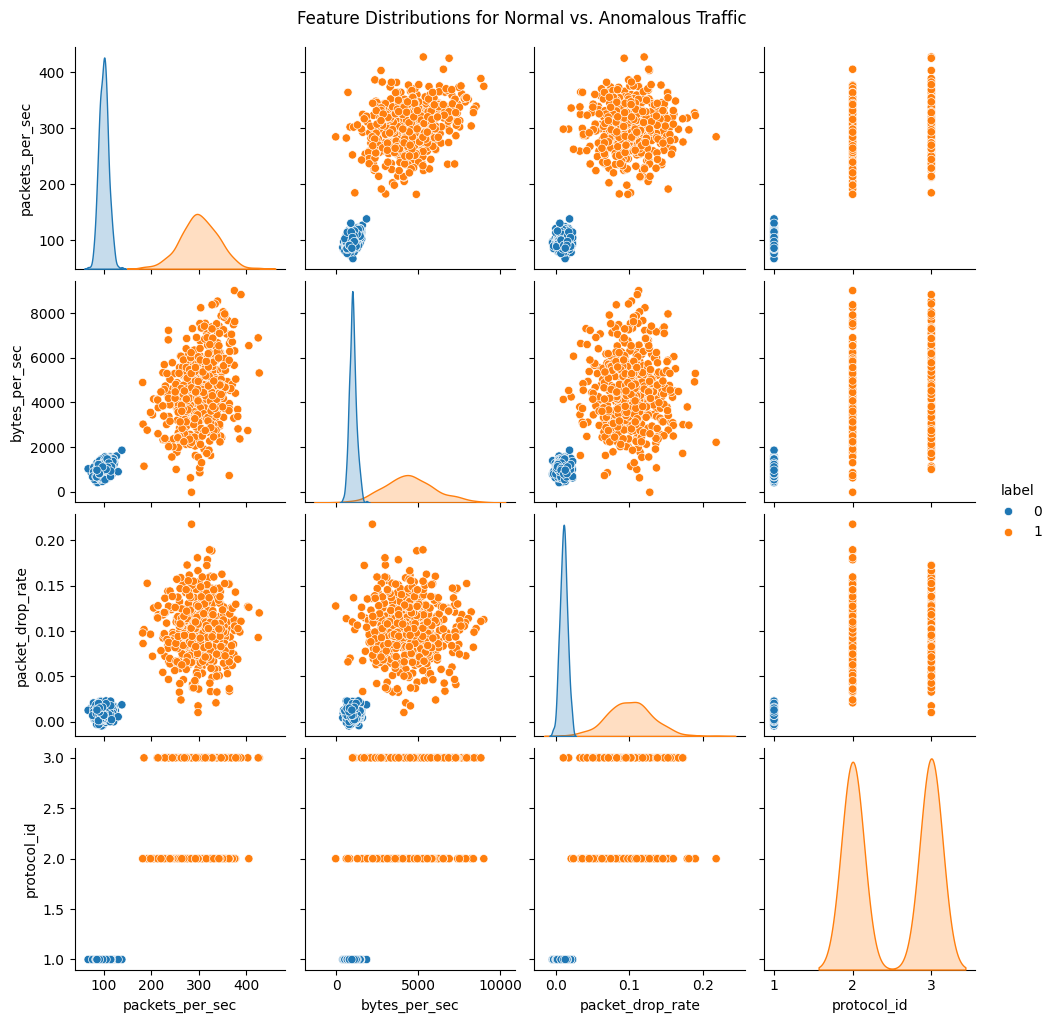

In [8]:
# Visualize
sns.pairplot(pd.DataFrame(X_df).assign(label=y), hue="label", diag_kind="kde")
plt.suptitle("Feature Distributions for Normal vs. Anomalous Traffic", y=1.02)

plot_path = RESULTS_DIR / "Data-Feature-distribution.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

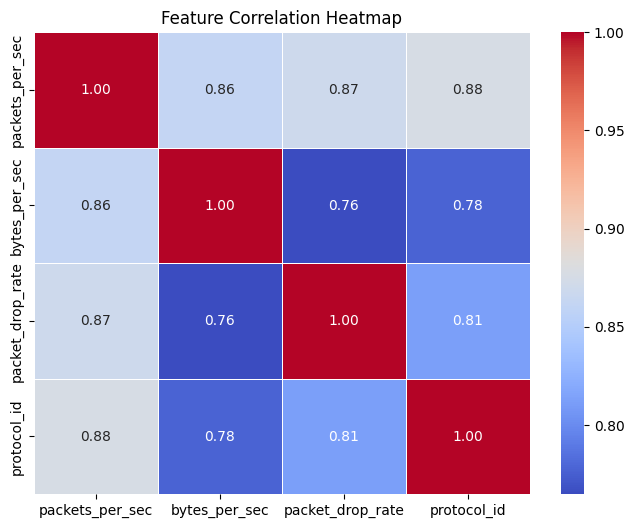

In [9]:
plt.figure(figsize=(8, 6))
corr = X_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")

plot_path = RESULTS_DIR / "Correlation-heatmap.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

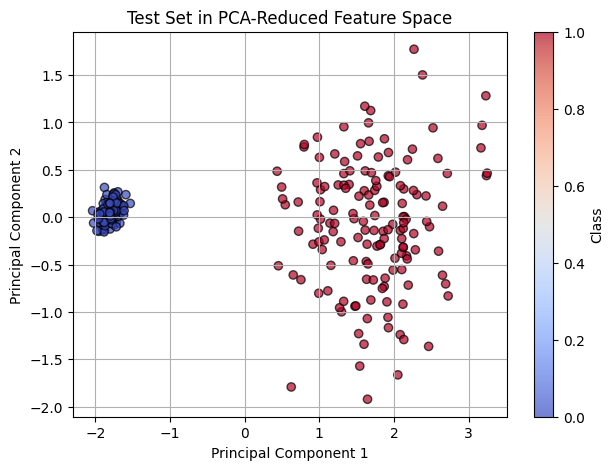

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.title("Test Set in PCA-Reduced Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(label='Class')

plot_path = RESULTS_DIR / "PCA.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


## 7. Quantum Model Configuration: ZZFeatureMap + RealAmplitudes + SPSA

We configure the **Variational Quantum Classifier (VQC)** using Qiskit Machine Learning. The model consists of:

- A `ZZFeatureMap` to encode classical input features into quantum states
- A `RealAmplitudes` ansatz that defines trainable rotational layers in the circuit
- A `SPSA` optimizer for variational parameter tuning

We also visualize both the feature map and ansatz to understand the model structure.


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3074246672.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3074246672.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=4, reps=2, entanglement='linear')


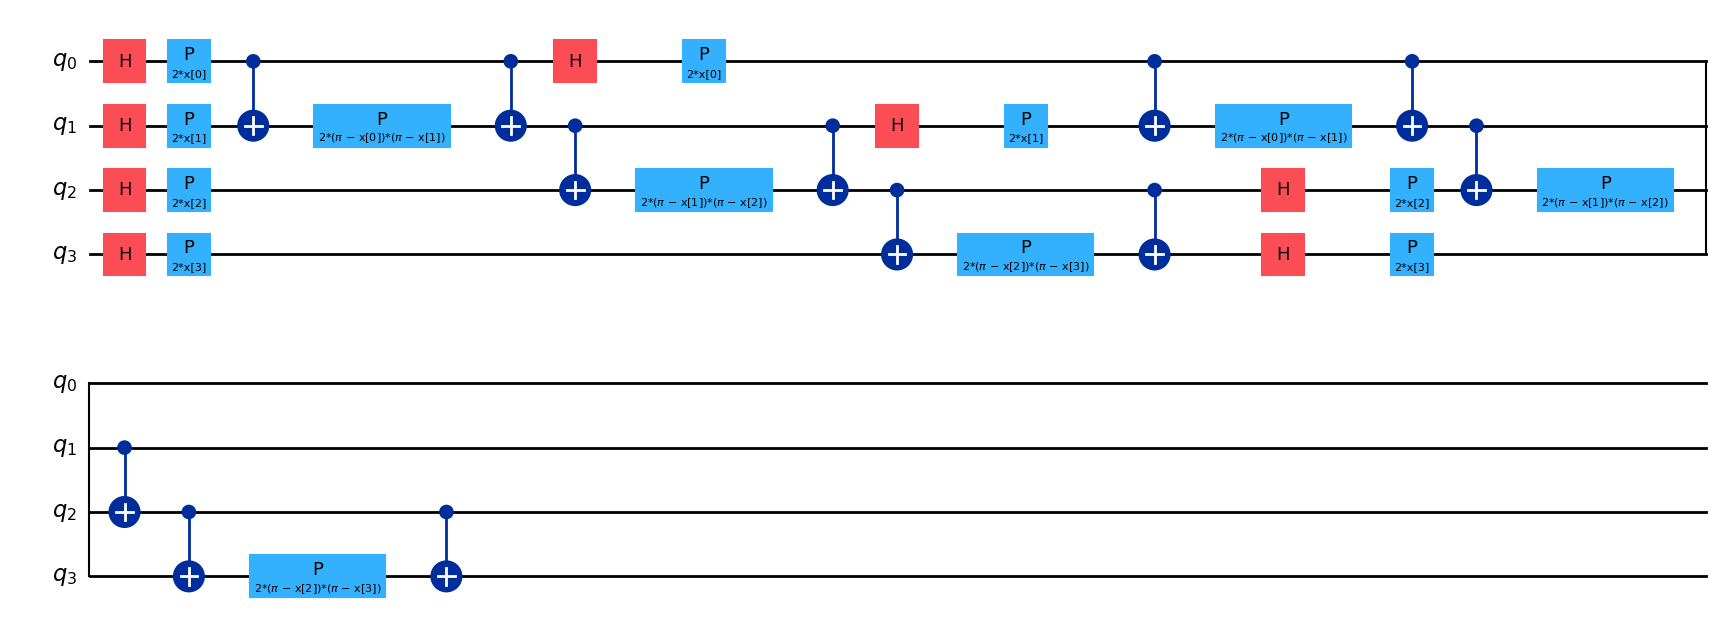

In [11]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

# Feature map and ansatz
feature_map = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
ansatz = RealAmplitudes(num_qubits=4, reps=2, entanglement='linear')

# Visualize circuits
feature_map.decompose().draw('mpl')


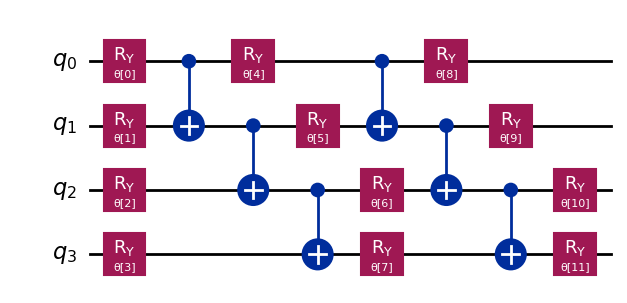

In [12]:

ansatz.decompose().draw('mpl')



## 8. Training and Optimizer Monitoring

We use the `SPSA` optimizer with a callback function to record and plot loss values during training.


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\1103188453.py:24: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(4, reps=2, entanglement="linear")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\1103188453.py:25: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(4, reps=2, entanglement="linear")
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


>>> Starting training...
[003] Loss = 1.214621
[006] Loss = 1.131874
[009] Loss = 0.925002
[012] Loss = 0.856924
[015] Loss = 0.854455
[018] Loss = 0.850369
[021] Loss = 0.847898
[024] Loss = 0.838455
[027] Loss = 0.819042
[030] Loss = 0.817706
[033] Loss = 0.818404
[036] Loss = 0.806157
[039] Loss = 0.807897
[042] Loss = 0.801265
[045] Loss = 0.799944
[048] Loss = 0.798626
[051] Loss = 0.799559
[054] Loss = 0.796910
[057] Loss = 0.795769
[060] Loss = 0.787570
[063] Loss = 0.781266
[066] Loss = 0.781477
[069] Loss = 0.777521
[072] Loss = 0.769209
[075] Loss = 0.766242
[078] Loss = 0.762810
[081] Loss = 0.759618
[084] Loss = 0.756637
[087] Loss = 0.757308
[090] Loss = 0.754881
[093] Loss = 0.750450
[096] Loss = 0.744750
[099] Loss = 0.740272
[102] Loss = 0.738478
[105] Loss = 0.739464
[108] Loss = 0.737591
[111] Loss = 0.727134
[114] Loss = 0.727214
[117] Loss = 0.725928
[120] Loss = 0.726345
[123] Loss = 0.726868
[126] Loss = 0.722923
[129] Loss = 0.723871
[132] Loss = 0.722771
[135] L

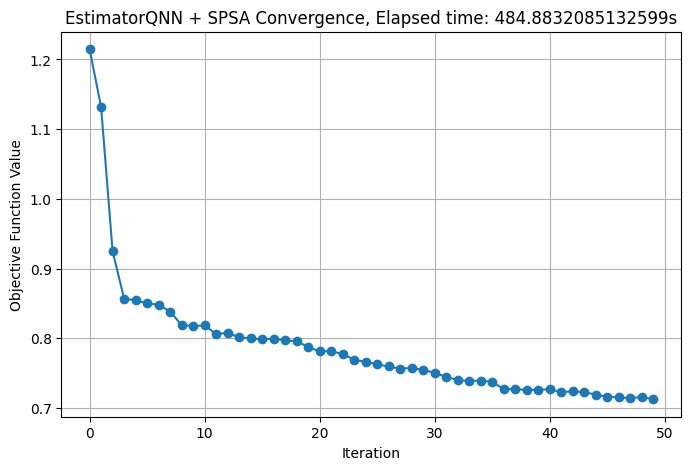

In [13]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_algorithms.optimizers import SPSA
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt
import time

# =========================
# Setup
# =========================
loss_vals = []

# ✅ THIS CALLBACK *WILL* BE CALLED
def spsa_callback(nfev, params, value, stepsize, accepted):
    print(f"[{nfev:03}] Loss = {value:.6f}", flush=True)
    loss_vals.append(value)

# =========================
# Quantum Circuit
# =========================
feature_map = ZZFeatureMap(4, reps=2, entanglement="linear")
ansatz = RealAmplitudes(4, reps=2, entanglement="linear")

qc = QuantumCircuit(4)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# =========================
# Estimator + QNN (V2)
# =========================
estimator = StatevectorEstimator()

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator
)

optimizer = SPSA(maxiter=params['maxiter'])

classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=optimizer,
    callback=spsa_callback,
    initial_point=np.random.uniform(-1, 1, qnn.num_weights)
)

# =========================
# Train
# =========================
print(">>> Starting training...")
start = time.time()

y_train_modified = np.where(y_train == 0, -1, 1)
classifier.fit(X_train_scaled, y_train_modified)

end = time.time()
print(">>> Training complete.")
print(f"Elapsed time: {end - start:.2f} seconds")
print(f"Loss values recorded: {len(loss_vals)}")

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(loss_vals, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Objective Function Value")
plt.title(f"EstimatorQNN + SPSA Convergence, Elapsed time: {end - start}s")
plt.grid(True)

plot_path = RESULTS_DIR / "VQC-Model-1-Loss-Curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


## 9. Evaluation Metrics

We evaluate the VQC model using standard classification metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix



▶ Evaluation Metrics (VQC-1)
Accuracy : 0.670
Precision: 0.750
Recall   : 0.670
F1 Score : 0.641


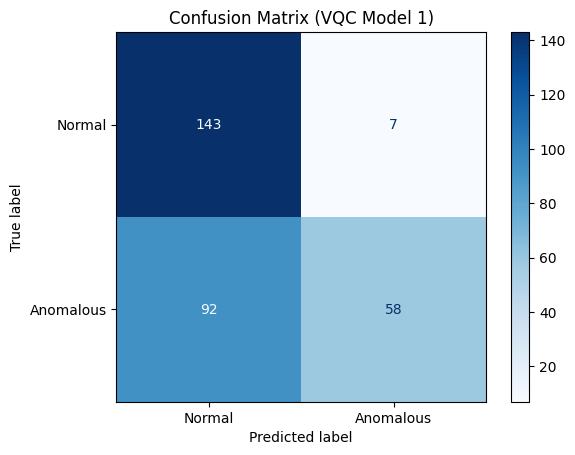

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# =========================
# PREDICTION
# =========================
y_pred = classifier.predict(X_test_scaled)
# Ensure numpy array
y_pred = np.asarray(y_pred)
y_pred = np.where(y_pred == -1, 0, 1)

# =========================
# METRICS (ROBUST)
# =========================
acc_1 = accuracy_score(y_test, y_pred)

# Use macro average to handle binary OR multiclass safely
prec_1 = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_1  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("\n▶ Evaluation Metrics (VQC-1)")
print(f"Accuracy : {acc_1:.3f}")
print(f"Precision: {prec_1:.3f}")
print(f"Recall   : {rec_1:.3f}")
print(f"F1 Score : {f1_1:.3f}")

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomalous"])
disp.plot(cmap='Blues', values_format="d")
plt.title("Confusion Matrix (VQC Model 1)")

plot_path = RESULTS_DIR / "VQC-Model-1-Evaluation-Metrics-and-CM.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

metrics["VQC-Model-1"] = {
    "training_time_seconds": float(end - start),
    "evaluation_metrics": {
        "accuracy": float(acc_1),
        "precision": float(prec_1),
        "recall": float(rec_1),
        "f1_score": float(f1_1)
    },
    "confusion_matrix": cm.tolist()
}



## 10. Second Quantum Model: PauliFeatureMap + TwoLocal + SPSA

We now configure a second variational quantum classifier using a different feature map and ansatz:

- **Feature Map:** `PauliFeatureMap` (supports more expressivity using 'X', 'Y', 'Z')
- **Ansatz:** `TwoLocal` (a flexible layered ansatz with entanglement)
- **Optimizer:** `SPSA` (Simultaneous Perturbation Stochastic Approximation), suited for noisy training

This model is trained completely separately from the first one. The training, circuit structure, loss tracking, and evaluation are shown in full below.


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\4181062359.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation.pauli_feature_map.PauliFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the pauli_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map_2 = PauliFeatureMap(feature_dimension=4, reps=2, paulis=['X', 'Y', 'Z'])
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\4181062359.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz_2 = TwoLocal(num_qubits=4, reps=2, rotation_blocks='ry', entanglement_blocks='cz', entanglement='linear')


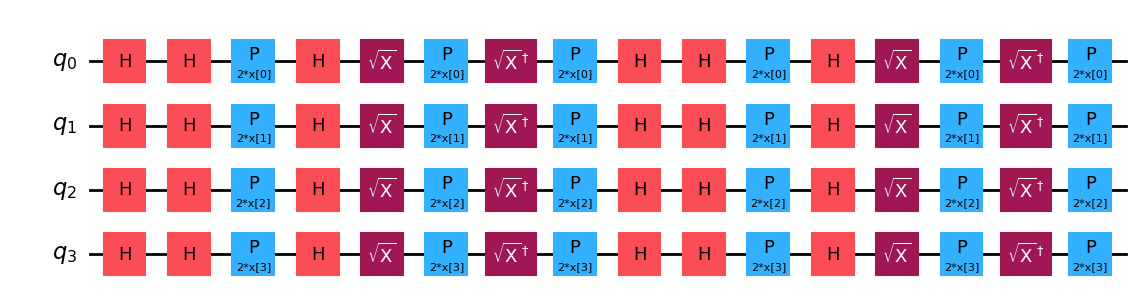

In [15]:

from qiskit.circuit.library import PauliFeatureMap, TwoLocal
from qiskit_algorithms.optimizers import SPSA

# Define the new feature map and ansatz
feature_map_2 = PauliFeatureMap(feature_dimension=4, reps=2, paulis=['X', 'Y', 'Z'])
ansatz_2 = TwoLocal(num_qubits=4, reps=2, rotation_blocks='ry', entanglement_blocks='cz', entanglement='linear')

# Visualize circuits
feature_map_2.decompose().draw('mpl')


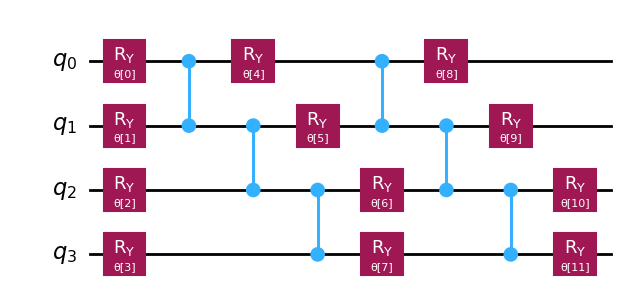

In [16]:
ansatz_2.decompose().draw('mpl')

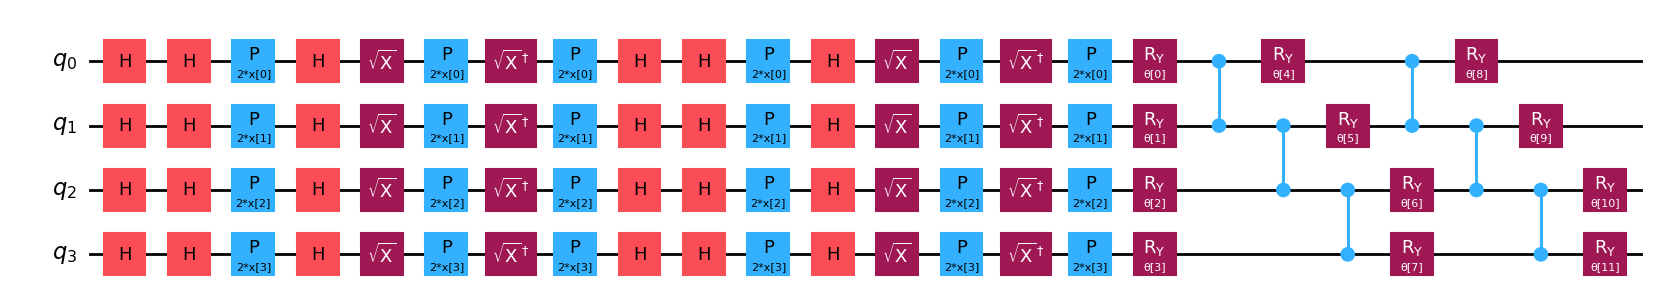

In [17]:
qc_full = QuantumCircuit(4)
qc_full.compose(feature_map_2, inplace=True)
qc_full.compose(ansatz_2, inplace=True)

# Visualize Full VQC Circuit
qc_full.decompose().draw('mpl')


### 10.1 Training with SPSA Optimizer
SPSA is a gradient-free optimizer that is well-suited for quantum noisy environments. We track the loss function using a callback and monitor convergence.


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\2631727868.py:17: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation.pauli_feature_map.PauliFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the pauli_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map_2 = PauliFeatureMap(feature_dimension=4, reps=2, paulis=['X', 'Y', 'Z'])
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\2631727868.py:18: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz_2 = TwoLocal(num_qubits=4, reps=2, rotation_blocks='ry', entanglement_blocks='cz', entanglement='linear')
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


>>> Starting training...
[003] Loss: 0.503230
[006] Loss: 0.505834
[009] Loss: 0.464209
[012] Loss: 0.465603
[015] Loss: 0.462626
[018] Loss: 0.461297
[021] Loss: 0.461748
[024] Loss: 0.461239
[027] Loss: 0.460061
[030] Loss: 0.459743
[033] Loss: 0.460861
[036] Loss: 0.458364
[039] Loss: 0.453382
[042] Loss: 0.452497
[045] Loss: 0.449556
[048] Loss: 0.450134
[051] Loss: 0.448790
[054] Loss: 0.449572
[057] Loss: 0.448657
[060] Loss: 0.448083
[063] Loss: 0.446189
[066] Loss: 0.446193
[069] Loss: 0.446258
[072] Loss: 0.444580
[075] Loss: 0.445333
[078] Loss: 0.443823
[081] Loss: 0.443126
[084] Loss: 0.443178
[087] Loss: 0.441249
[090] Loss: 0.441013
[093] Loss: 0.440319
[096] Loss: 0.439609
[099] Loss: 0.439358
[102] Loss: 0.439449
[105] Loss: 0.439581
[108] Loss: 0.440082
[111] Loss: 0.438446
[114] Loss: 0.440473
[117] Loss: 0.439304
[120] Loss: 0.439308
[123] Loss: 0.438061
[126] Loss: 0.438937
[129] Loss: 0.437959
[132] Loss: 0.438136
[135] Loss: 0.436840
[138] Loss: 0.438315
[141] Los

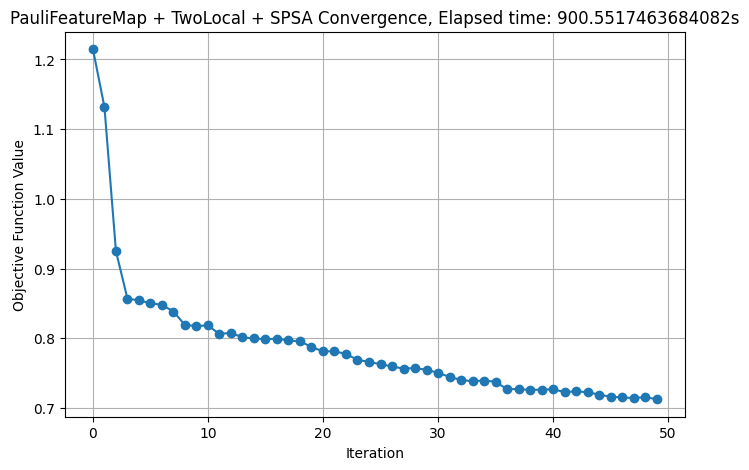

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit import QuantumCircuit
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_algorithms.optimizers import SPSA

# ----------------------------
# Define Quantum Circuit & QNN
# ----------------------------
# Define the new feature map and ansatz
feature_map_2 = PauliFeatureMap(feature_dimension=4, reps=2, paulis=['X', 'Y', 'Z'])
ansatz_2 = TwoLocal(num_qubits=4, reps=2, rotation_blocks='ry', entanglement_blocks='cz', entanglement='linear')

qc = QuantumCircuit(4)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

sampler = StatevectorSampler()

num_qubits = qc.num_qubits # Get the number of qubits from the circuit

def interpret_qnn_output(bitstring_int, num_qubits):
    if (bitstring_int % 2) == 0:
        return 0
    else:
        return 1

qnn = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    sampler=sampler,
    output_shape=2,
    interpret=lambda x: interpret_qnn_output(x, num_qubits)
)

# ----------------------------
# Define Classifier
# ----------------------------
loss_vals_2 = [] # Renamed to loss_vals_2
def callback(nfev, params, value, stepsize, accepted):
    print(f"[{nfev:03}] Loss: {value:.6f}")
    loss_vals_2.append(value)

optimizer = SPSA(maxiter=params['maxiter'])

classifier_2 = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=optimizer,
    callback=callback,
    initial_point=np.random.uniform(-1, 1, qnn.num_weights)
)

# =========================
# Train
# =========================
print(">>> Starting training...")
start = time.time()

classifier_2.fit(X_train_scaled, y_train)

end = time.time()
print(">>> Training complete.")
print(f"Elapsed time: {end - start:.2f} seconds")
print(f"Loss values recorded: {len(loss_vals)}")

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(loss_vals, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Objective Function Value")

plt.title(f"PauliFeatureMap + TwoLocal + SPSA Convergence, Elapsed time: {end - start}s")
plt.grid(True)

plot_path = RESULTS_DIR / "VQC-Model-2-Loss-Curve.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


### 10.2 Evaluation of Model 2
We now compute the accuracy, precision, recall, F1-score, and confusion matrix for the second VQC model.


Accuracy: 0.577
Precision: 0.645
Recall: 0.577
F1 Score: 0.520


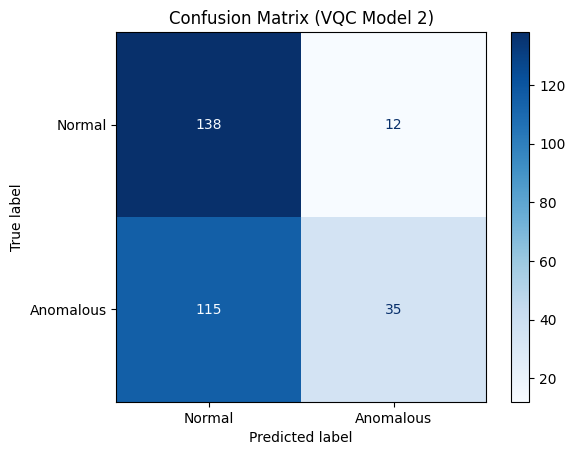

In [19]:
# ----------------------------
# Evaluation
# ----------------------------
y_pred_2 = classifier_2.predict(X_test_scaled) # Renamed to y_pred_2
acc_2 = accuracy_score(y_test, y_pred_2) # Renamed to acc_2
prec_2 = precision_score(y_test, y_pred_2, average="macro", zero_division=0) # Renamed to prec_2
rec_2  = recall_score(y_test, y_pred_2, average="macro", zero_division=0) # Renamed to rec_2
f1_2   = f1_score(y_test, y_pred_2, average="macro", zero_division=0) # Renamed to f1_2

print(f"Accuracy: {acc_2:.3f}")
print(f"Precision: {prec_2:.3f}")
print(f"Recall: {rec_2:.3f}")
print(f"F1 Score: {f1_2:.3f}")

cm_2 = confusion_matrix(y_test, y_pred_2) # Renamed to cm_2
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=["Normal", "Anomalous"])
disp_2.plot(cmap='Blues')
plt.title("Confusion Matrix (VQC Model 2)")

plot_path = RESULTS_DIR / "VQC-Model-2-Evaluation-Metrics-and-CM.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

metrics["VQC-Model-2"] = {
    "training_time_seconds": float(end - start),
    "evaluation_metrics": {
        "accuracy": float(acc_2),
        "precision": float(prec_2),
        "recall": float(rec_2),
        "f1_score": float(f1_2)
    },
    "confusion_matrix": cm_2.tolist()
}



## 11. Third Quantum Model: ZFeatureMap + RealAmplitudes

This experiment tests a third quantum classifier using:

- **Feature Map:** `ZFeatureMap` — only Z-rotations (simplest encoding)
- **Ansatz:** `RealAmplitudes` (again used, but with more reps)
- **Optimizer:** `ADAM` 

We use this variation to examine the impact of simpler encoding on anomaly separation.


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3927700981.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map_3 = ZFeatureMap(feature_dimension=4, reps=2)
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3927700981.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_3 = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')


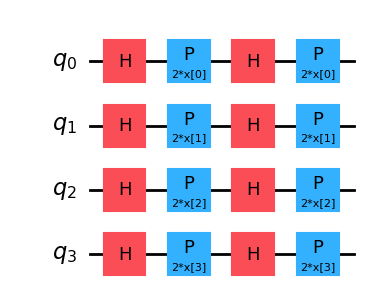

In [20]:
from qiskit.circuit.library import ZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import ADAM

feature_map_3 = ZFeatureMap(feature_dimension=4, reps=2)
ansatz_3 = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')

# Visualize the circuit
feature_map_3.decompose().draw('mpl')

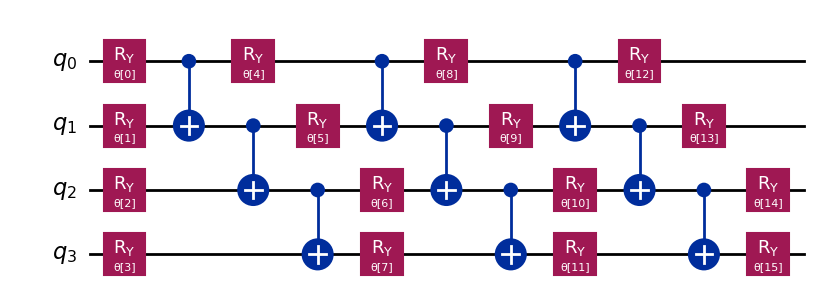

In [21]:
ansatz_3.decompose().draw('mpl')


### 11.1 Training with ADAM Optimizer


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\1869564618.py:12: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map_3 = ZFeatureMap(feature_dimension=4, reps=2)
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\1869564618.py:13: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_3 = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


>>> Starting training with ADAM Optimizer for VQC Model 3...
[001] Loss = 1.196879
[002] Loss = 1.022628
[003] Loss = 0.849649
[004] Loss = 0.724677
[005] Loss = 0.649113
[006] Loss = 0.608210
[007] Loss = 0.583470
[008] Loss = 0.556476
[009] Loss = 0.538552
[010] Loss = 0.528345
[011] Loss = 0.527806
[012] Loss = 0.535877
[013] Loss = 0.542770
[014] Loss = 0.547639
[015] Loss = 0.549833
[016] Loss = 0.547917
[017] Loss = 0.547162
[018] Loss = 0.544751
[019] Loss = 0.544164
[020] Loss = 0.545771
[021] Loss = 0.541735
[022] Loss = 0.536440
[023] Loss = 0.526730
[024] Loss = 0.518953
[025] Loss = 0.514986
[026] Loss = 0.511106
[027] Loss = 0.508213
[028] Loss = 0.502837
[029] Loss = 0.499140
[030] Loss = 0.492354
[031] Loss = 0.487457
[032] Loss = 0.482694
[033] Loss = 0.478927
[034] Loss = 0.475733
[035] Loss = 0.475547
[036] Loss = 0.474948
[037] Loss = 0.473660
[038] Loss = 0.474101
[039] Loss = 0.474529
[040] Loss = 0.475489
[041] Loss = 0.475170
[042] Loss = 0.474676
[043] Loss = 0.

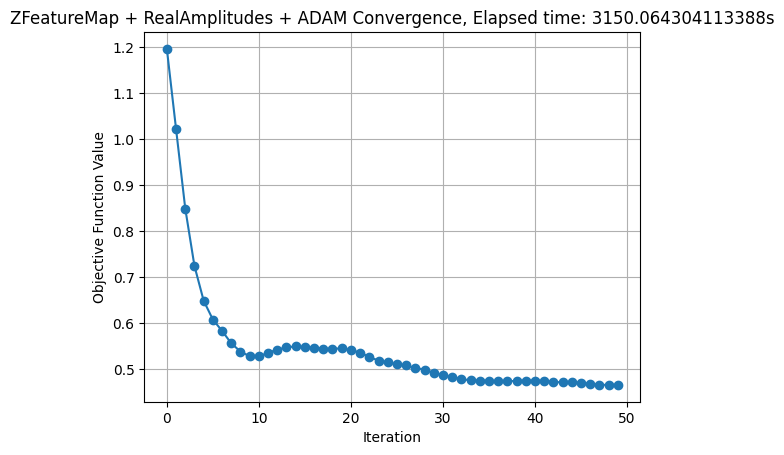

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import time

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZFeatureMap, RealAmplitudes # Import ZFeatureMap and RealAmplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import ADAM

feature_map_3 = ZFeatureMap(feature_dimension=4, reps=2)
ansatz_3 = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')

# ==============================
# CIRCUIT (using feature_map_3 and ansatz_3)
# ==============================
qc_3 = QuantumCircuit(feature_map_3.num_qubits)
qc_3.compose(feature_map_3, inplace=True)
qc_3.compose(ansatz_3, inplace=True)

# ==============================
# QNN + Estimator
# ==============================
estimator = StatevectorEstimator()

qnn_3 = EstimatorQNN(
    circuit=qc_3,
    input_params=feature_map_3.parameters,
    weight_params=ansatz_3.parameters,
    estimator=estimator
)

# ==============================
# LOSS TRACKING
# ==============================
loss_vals_3 = []

def adam_callback(step, weights, loss):
    loss_vals_3.append(loss)
    print(f"[{step:03}] Loss = {loss:.6f}")

# ==============================
# OPTIMIZER
# ==============================
# optimizer_3 = ADAM(maxiter=40, lr=0.1)
optimizer_3 = ADAM(
    maxiter=params['maxiter'],
    lr=0.1,
)
# ==============================
# CLASSIFIER
# ==============================
classifier_3 = NeuralNetworkClassifier(
    neural_network=qnn_3,
    optimizer=optimizer_3,
    callback=adam_callback, # Use adam_callback
    initial_point=np.random.uniform(-0.1, 0.1, qnn_3.num_weights),
    one_hot=False # Still false, as target y_train is 1D binary
)

# ==============================
# TRAIN
# ==============================
print(">>> Starting training with ADAM Optimizer for VQC Model 3...")
start = time.time()
# Use the globally available X_train_scaled, y_train from section 5
y_train_modified = np.where(y_train == 0, -1, 1)
classifier_3.fit(X_train_scaled, y_train_modified)
end = time.time()
print(">>> Training complete for VQC Model 3.")
print(f"Elapsed time: {end - start:.2f} seconds")

# ==============================
# PLOT LOSS
# ==============================
if loss_vals_3:
    plt.plot(loss_vals_3, marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("Objective Function Value")

    plt.title(f"ZFeatureMap + RealAmplitudes + ADAM Convergence, Elapsed time: {end - start}s")
    plt.grid(True)
    
    plot_path = RESULTS_DIR / "VQC-Model-3-Loss-Curve.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    plt.show()
else:
    print("⚠️ No loss values recorded for VQC Model 3. (Callback not supported by NeuralNetworkClassifier for ADAM optimizer.)")



### 11.2 Evaluation of Model 3


Accuracy: 0.863
Precision: 0.893
Recall: 0.863
F1 Score: 0.861


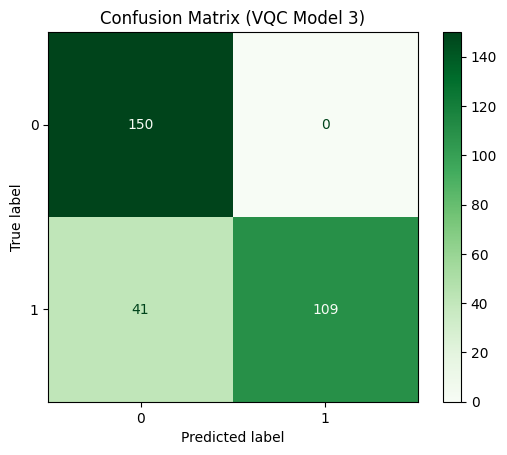

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred_3 = classifier_3.predict(X_test_scaled)
# Ensure numpy array
y_pred_3 = np.asarray(y_pred_3)
y_pred_3 = np.where(y_pred_3 == -1, 0, 1)

acc_3 = accuracy_score(y_test, y_pred_3)
prec_3 = precision_score(y_test, y_pred_3, average='macro')
rec_3  = recall_score(y_test, y_pred_3, average='macro')
f1_3   = f1_score(y_test, y_pred_3, average='macro')

print(f"Accuracy: {acc_3:.3f}")
print(f"Precision: {prec_3:.3f}")
print(f"Recall: {rec_3:.3f}")
print(f"F1 Score: {f1_3:.3f}")

cm_3 = confusion_matrix(y_test, y_pred_3)
disp_3 = ConfusionMatrixDisplay(confusion_matrix=cm_3)
disp_3.plot(cmap='Greens')
plt.title("Confusion Matrix (VQC Model 3)")

plot_path = RESULTS_DIR / "VQC-Model-3-Evaluation-Metrics-and-CM.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

metrics["VQC-Model-3"] = {
    "training_time_seconds": float(end - start),
    "evaluation_metrics": {
        "accuracy": float(acc_3),
        "precision": float(prec_3),
        "recall": float(rec_3),
        "f1_score": float(f1_3)
    },
    "confusion_matrix": cm_3.tolist()
}



## 12. Fourth Quantum Model: Deeper Circuit (ZZFeatureMap + RealAmplitudes, reps=4)

To expand the quantum model exploration, we now test a **deeper parameterized quantum circuit** by increasing the number of repetitions (`reps`) in both the feature map and the ansatz. This increases circuit expressibility, which might help capture more subtle patterns in the data.

This experiment uses:

- `ZZFeatureMap(feature_dimension=4, reps=4)`
- `RealAmplitudes(num_qubits=4, reps=4)`
- `COBYLA` optimizer (used previously for consistency)


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3216481727.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map_4 = ZZFeatureMap(feature_dimension=4, reps=4, entanglement='linear')
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3216481727.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_4 = RealAmplitudes(num_qubits=4, reps=4, entanglement='linear')


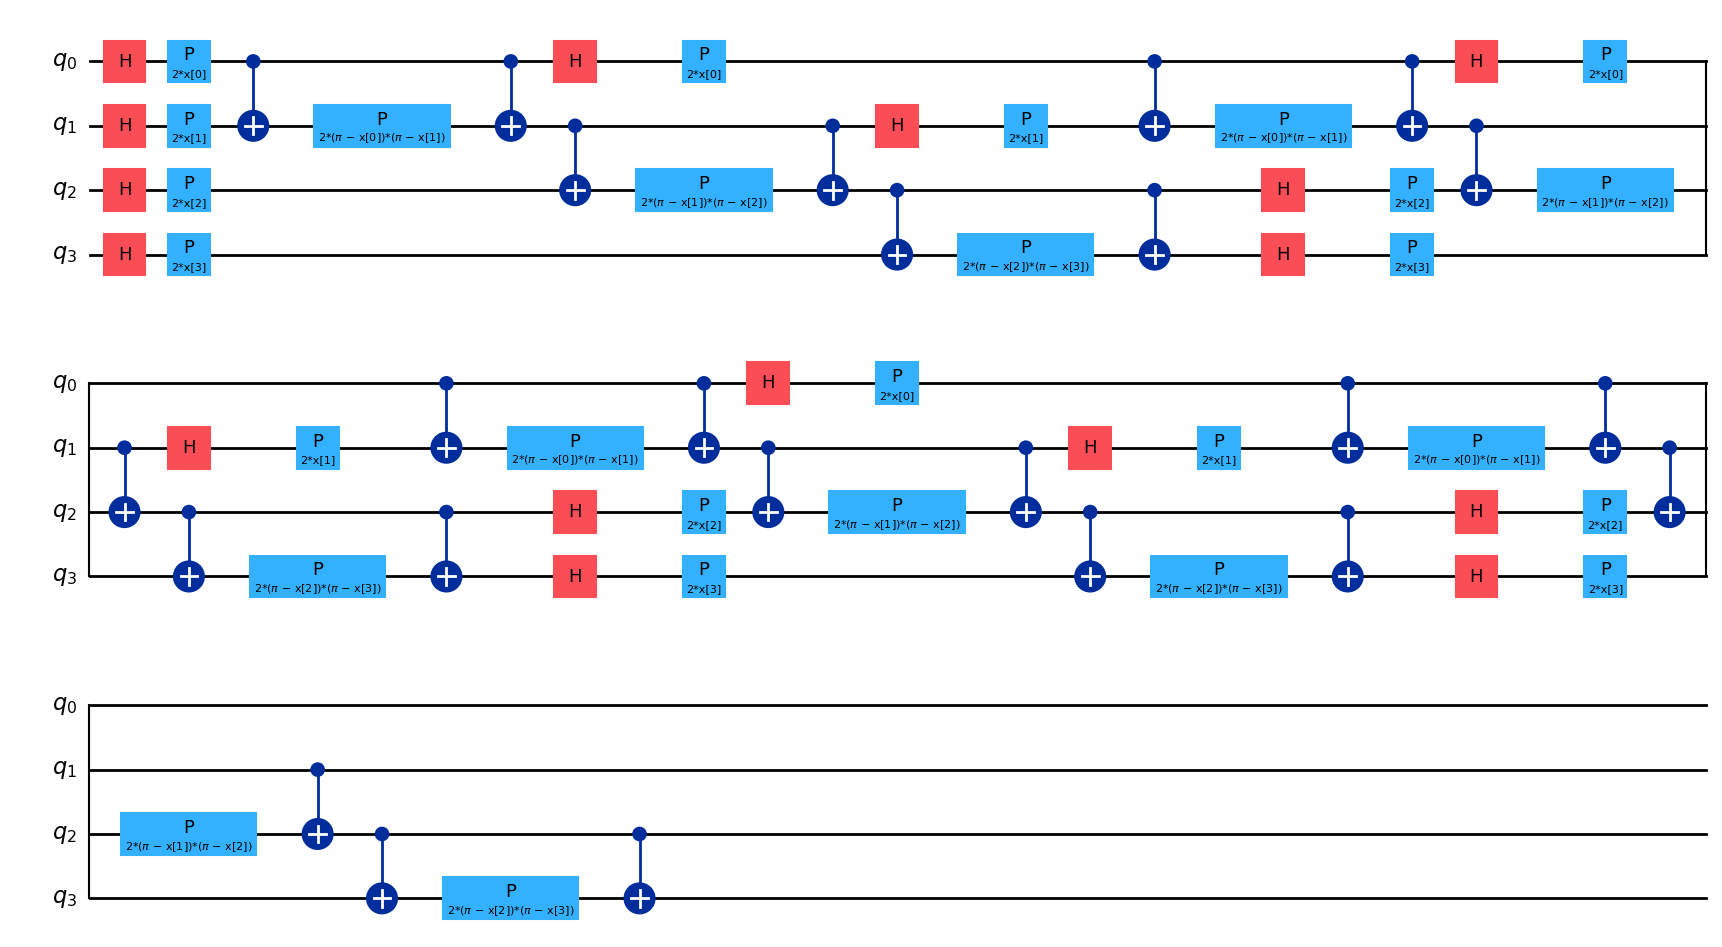

In [24]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
import qiskit.visualization # Re-import to refresh dependency check
import matplotlib.pyplot as plt # Ensure pyplot is imported for plotting

feature_map_4 = ZZFeatureMap(feature_dimension=4, reps=4, entanglement='linear')
ansatz_4 = RealAmplitudes(num_qubits=4, reps=4, entanglement='linear')

feature_map_4.decompose().draw('mpl')


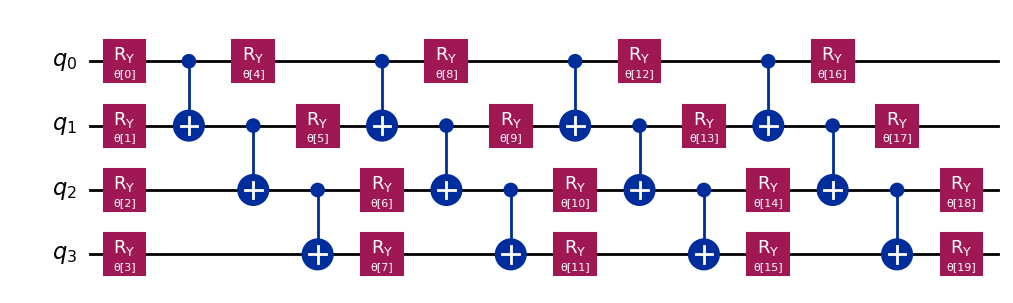

In [25]:
ansatz_4.decompose().draw('mpl')


### 12.1 Training the Deeper Quantum Circuit with COBYLA


C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3183754760.py:14: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map_4 = ZZFeatureMap(feature_dimension=4, reps=4, entanglement='linear')
C:\Users\HP USER\AppData\Local\Temp\ipykernel_9668\3183754760.py:15: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_4 = RealAmplitudes(num_qubits=4, reps=4, entanglement='linear')
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


>>> Starting training VQC Model 4 (Deep Circuit)...
[001] Loss = 0.835558
[002] Loss = 0.834930
[003] Loss = 0.837206
[004] Loss = 0.834425
[005] Loss = 0.836155
[006] Loss = 0.815731
[007] Loss = 0.815328
[008] Loss = 0.814036
[009] Loss = 0.810074
[010] Loss = 0.813683
[011] Loss = 0.807223
[012] Loss = 0.807082
[013] Loss = 0.804451
[014] Loss = 0.804246
[015] Loss = 0.796694
[016] Loss = 0.782490
[017] Loss = 0.777325
[018] Loss = 0.774672
[019] Loss = 0.769907
[020] Loss = 0.766026
[021] Loss = 0.764091
>>> Training complete for VQC Model 4.
⏱️ Elapsed time: 279.88 seconds
Loss values recorded: 21


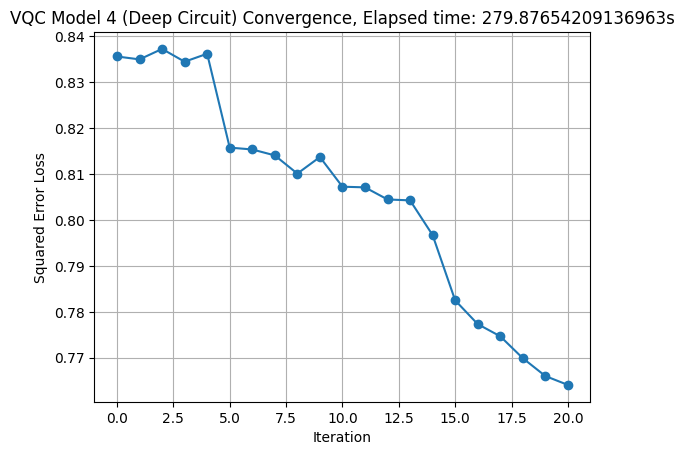

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import time
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_algorithms.optimizers import COBYLA

# ==============================
# Define Feature Map and Ansatz
# ==============================
feature_map_4 = ZZFeatureMap(feature_dimension=4, reps=4, entanglement='linear')
ansatz_4 = RealAmplitudes(num_qubits=4, reps=4, entanglement='linear')

# ==============================
# CIRCUIT
# ==============================
qc_4 = QuantumCircuit(feature_map_4.num_qubits)
qc_4.compose(feature_map_4, inplace=True)
qc_4.compose(ansatz_4, inplace=True)

# ==============================
# QNN + Estimator
# ==============================
estimator = StatevectorEstimator()
qnn_4 = EstimatorQNN(
    circuit=qc_4,
    input_params=feature_map_4.parameters,
    weight_params=ansatz_4.parameters,
    estimator=estimator
)

# ==============================
# LOSS TRACKING CALLBACK (Squared Error - Matches NeuralNetworkClassifier default)
# ==============================
loss_vals_4 = []

def _create_cobyla_callback_with_loss_logging(qnn_instance, X_train_data, y_train_labels, loss_list):
    def cobyla_callback(current_params):
        try:
            # Forward pass: returns shape (n_samples, 1)
            y_pred = qnn_instance.forward(X_train_data, current_params).flatten()
            
            # Squared Error Loss (MSE) - This is what the optimizer is actually minimizing
            loss = np.mean((y_pred - y_train_labels) ** 2)
            
            loss_list.append(loss)
            print(f"[{len(loss_list):03}] Loss = {loss:.6f}")
        except Exception as e:
            print(f"[{len(loss_list)+1:03}] Error in callback: {e}")
            loss_list.append(np.nan)
    return cobyla_callback

# Convert labels to -1 / +1 for EstimatorQNN
y_train_modified = np.where(y_train == 0, -1.0, 1.0)

# Create callback
callback_4 = _create_cobyla_callback_with_loss_logging(qnn_4, X_train_scaled, y_train_modified, loss_vals_4)

# ==============================
# OPTIMIZER
# ==============================
optimizer_4 = COBYLA(maxiter=params['maxiter'], callback=callback_4)

# ==============================
# CLASSIFIER
# ==============================
vqc_4 = NeuralNetworkClassifier(
    neural_network=qnn_4,
    optimizer=optimizer_4,
    loss='squared_error',      # Explicitly set (this is the default)
    one_hot=False,
    initial_point=np.random.uniform(-1, 1, qnn_4.num_weights)
)

# ==============================
# TRAIN
# ==============================
print(">>> Starting training VQC Model 4 (Deep Circuit)...")
start = time.time()

vqc_4.fit(X_train_scaled, y_train_modified)

end = time.time()
print(">>> Training complete for VQC Model 4.")
print(f"⏱️ Elapsed time: {end - start:.2f} seconds")
print(f"Loss values recorded: {len(loss_vals_4)}")

# ==============================
# PLOT LOSS
# ==============================
if loss_vals_4:
    plt.plot(loss_vals_4, marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("Squared Error Loss")
    plt.title("Optimizer Convergence (VQC Model 4 - EstimatorQNN)")
    plt.grid(True)

    plt.title(f"VQC Model 4 (Deep Circuit) Convergence, Elapsed time: {end - start}s")
    plt.grid(True)
    
    plot_path = RESULTS_DIR / "VQC-Model-4-Loss-Curve.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    plt.show()
else:
    print("⚠️ No loss values were recorded.")


### 12.2 Evaluation of Model 4


Accuracy: 0.743
Precision: 0.747
Recall: 0.743
F1 Score: 0.742


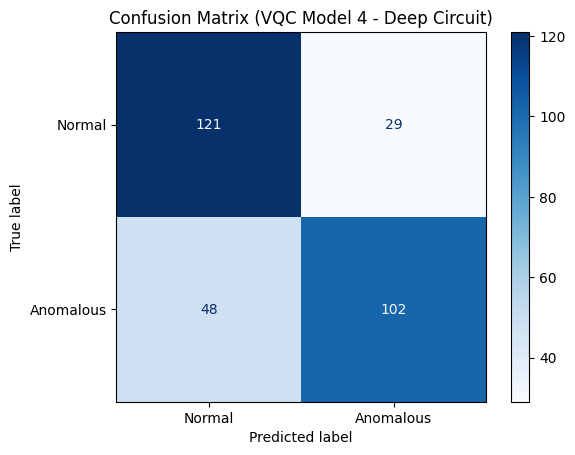

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for array operations

y_pred_4_raw = vqc_4.predict(X_test_scaled)

# Convert predicted labels from [-1, 1] to [0, 1] to match y_test
y_pred_4 = (y_pred_4_raw + 1) / 2

acc_4 = accuracy_score(y_test, y_pred_4)
prec_4 = precision_score(y_test, y_pred_4, average="macro", zero_division=0) # Added average and zero_division
rec_4 = recall_score(y_test, y_pred_4, average="macro", zero_division=0)    # Added average and zero_division
f1_4 = f1_score(y_test, y_pred_4, average="macro", zero_division=0)      # Added average and zero_division

print(f"Accuracy: {acc_4:.3f}")
print(f"Precision: {prec_4:.3f}")
print(f"Recall: {rec_4:.3f}")
print(f"F1 Score: {f1_4:.3f}")

cm_4 = confusion_matrix(y_test, y_pred_4)
disp_4 = ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=["Normal", "Anomalous"])
disp_4.plot(cmap='Blues')
plt.title("Confusion Matrix (VQC Model 4 - Deep Circuit)")

plot_path = RESULTS_DIR / "VQC-Model-4-Evaluation-Metrics-and-CM.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

metrics["VQC-Model-4"] = {
    "training_time_seconds": float(end - start),
    "evaluation_metrics": {
        "accuracy": float(acc_4),
        "precision": float(prec_4),
        "recall": float(rec_4),
        "f1_score": float(f1_4)
    },
    "confusion_matrix": cm_4.tolist()
}



## 13. Classical Model Benchmarks: SVM and Random Forest

To evaluate the performance of the quantum classifiers, we compare against strong classical baselines:

- **Support Vector Machine (SVM)** with RBF kernel
- **Random Forest Classifier**

All training and evaluation steps are performed independently and metrics are compared side-by-side with quantum models.


### 13.1 SVM

SVM Metrics:
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1 Score: 1.000


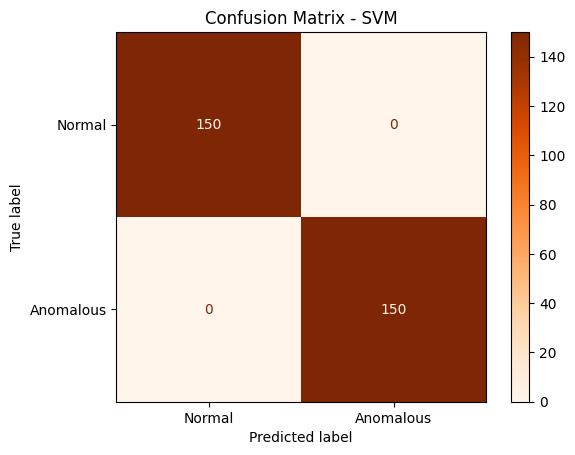

In [28]:
from sklearn.svm import SVC

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Metrics:")
print(f"Accuracy: {acc_svm:.3f}")
print(f"Precision: {prec_svm:.3f}")
print(f"Recall: {rec_svm:.3f}")
print(f"F1 Score: {f1_svm:.3f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Normal", "Anomalous"])
disp_svm.plot(cmap='Oranges')
plt.title("Confusion Matrix - SVM")

plot_path = RESULTS_DIR / "SVM-Evaluation-Metrics-and-CM.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

metrics["SVM"] = {
    "evaluation_metrics": {
        "accuracy": float(acc_svm),
        "precision": float(prec_svm),
        "recall": float(rec_svm),
        "f1_score": float(f1_svm)
    },
    "confusion_matrix": cm_svm.tolist()
}


### 13.2 Random Forest

Random Forest Metrics:
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1 Score: 1.000


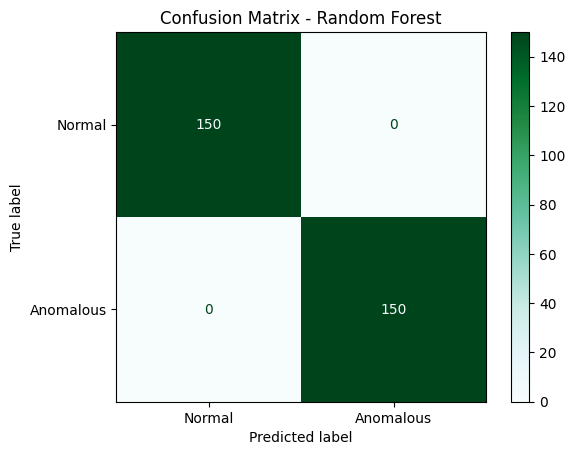

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Metrics:")
print(f"Accuracy: {acc_rf:.3f}")
print(f"Precision: {prec_rf:.3f}")
print(f"Recall: {rec_rf:.3f}")
print(f"F1 Score: {f1_rf:.3f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Anomalous"])
disp_rf.plot(cmap='BuGn')
plt.title("Confusion Matrix - Random Forest")

plot_path = RESULTS_DIR / "Random-Forest-Evaluation-Metrics-and-CM.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

metrics["RF"] = {
    "evaluation_metrics": {
        "accuracy": float(acc_rf),
        "precision": float(prec_rf),
        "recall": float(rec_rf),
        "f1_score": float(f1_rf)
    },
    "confusion_matrix": cm_rf.tolist()
}



## 14. Misclassification Analysis

Understanding where the model fails is critical in both classical and quantum settings. We analyze:

- Misclassified points from VQC Model 4
- Their PCA-projected positions
- Raw feature values for further insights


In [30]:
# Find misclassified indices
errors = np.where(y_pred_4.ravel() != y_test)[0]

# Create a DataFrame of misclassified samples
X_misclassified = X_test.iloc[errors]          # ← use .iloc here
y_true_misclassified = y_test[errors]
y_pred_misclassified = y_pred_4[errors]

misclassified_df = pd.DataFrame(
    X_misclassified, 
    columns=X_test.columns
)
misclassified_df['true_label'] = y_true_misclassified
misclassified_df['predicted_label'] = y_pred_misclassified

misclassified_df.head(10)


,packets_per_sec,bytes_per_sec,packet_drop_rate,protocol_id,true_label,predicted_label
723,324.614699,4575.080338,0.144450,3.0,1,0.0
524,285.111729,-27.815722,0.127654,2.0,1,0.0
752,273.836973,2120.626801,0.086026,2.0,1,0.0
568,237.498166,5251.972849,0.125754,2.0,1,0.0
1,98.617357,1362.776815,0.014623,1.0,0,1.0
651,313.031853,7295.943211,0.145579,3.0,1,0.0
952,263.770708,3867.962294,0.114000,3.0,1,0.0
841,224.726038,3843.908483,0.054501,2.0,1,0.0
306,112.776649,1177.869494,0.010141,1.0,0,1.0
583,302.467194,1064.410861,0.136707,3.0,1,0.0


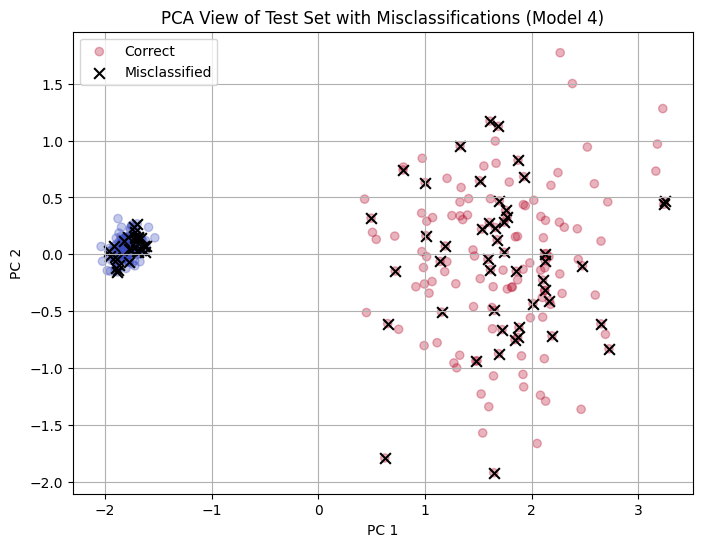

In [31]:
from sklearn.decomposition import PCA

# Re-perform PCA to ensure X_test_pca is defined in this scope
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Project all test data and overlay errors
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', label='Correct', alpha=0.3)
plt.scatter(X_test_pca[errors, 0], X_test_pca[errors, 1], c='black', marker='x', label='Misclassified', s=60)
plt.title("PCA View of Test Set with Misclassifications (Model 4)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.grid(True)

plot_path = RESULTS_DIR / "VQC-Model-4-Misclassification-analysis-PCA.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


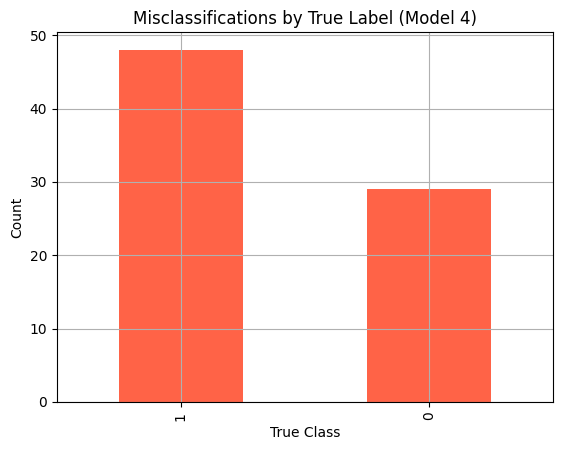

In [32]:

# Count how often each class was misclassified
misclassified_counts = misclassified_df['true_label'].value_counts()
misclassified_counts.plot(kind='bar', color='tomato')
plt.title("Misclassifications by True Label (Model 4)")
plt.xlabel("True Class")
plt.ylabel("Count")
plt.grid(True)

plot_path = RESULTS_DIR / "VQC-Model-4-Misclassifications-by-true-label.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()



## 15. Summary of Results

Below is a summary table comparing the performance of all quantum and classical models tested in this project.


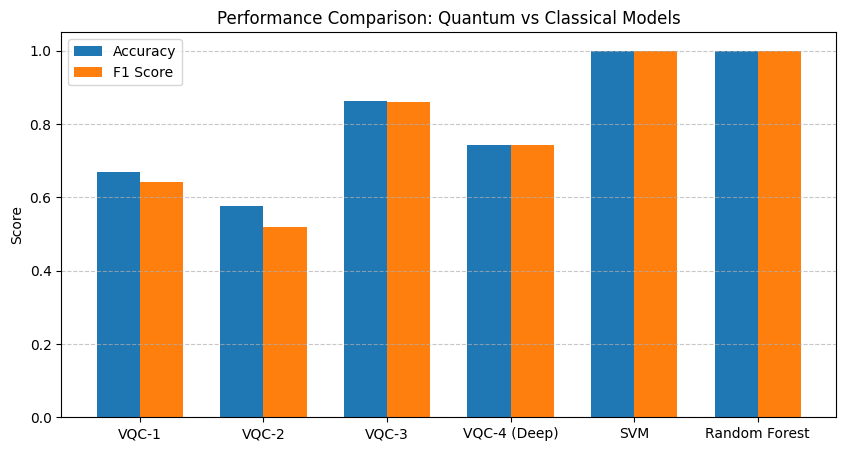

In [33]:

import pandas as pd
import numpy as np # Import numpy for np.arange
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Aggregate results
model_names = ["VQC-1", "VQC-2", "VQC-3", "VQC-4 (Deep)", "SVM", "Random Forest"]
accuracies = [acc_1, acc_2, acc_3, acc_4, acc_svm, acc_rf]
f1_scores = [f1_1, f1_2, f1_3, f1_4, f1_svm, f1_rf]

# Bar plot comparison
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, accuracies, width, label='Accuracy')
plt.bar(x + width/2, f1_scores, width, label='F1 Score')
plt.xticks(x, model_names)
plt.ylabel("Score")
plt.title("Performance Comparison: Quantum vs Classical Models")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plot_path = RESULTS_DIR / "Performance-comparison-of-all-models.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


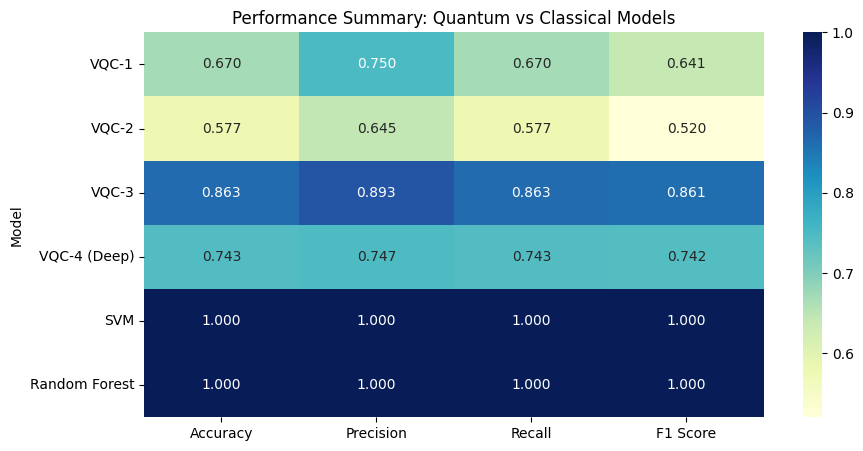

In [34]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-create summary_df as it's needed for this plot
# Assuming model_names, accuracies, prec_1, rec_1, f1_1, etc. are defined from previous cells
model_names = ["VQC-1", "VQC-2", "VQC-3", "VQC-4 (Deep)", "SVM", "Random Forest"]

# Aggregate results - ensure all are available from previous executions
accuracies = [acc_1, acc_2, acc_3, acc_4, acc_svm, acc_rf]
precisions = [prec_1, prec_2, prec_3, prec_4, prec_svm, prec_rf]
recalls = [rec_1, rec_2, rec_3, rec_4, rec_svm, rec_rf]
f1_scores = [f1_1, f1_2, f1_3, f1_4, f1_svm, f1_rf]

summary_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
})

summary_df.set_index('Model', inplace=True)

plt.figure(figsize=(10, 5))
sns.heatmap(summary_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Performance Summary: Quantum vs Classical Models")

plot_path = RESULTS_DIR / "Performance-summary-of-all-models.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


In [35]:
# ----------------------------
# Save metrics to experiments/metrics_runX.json
# ----------------------------
run_number = params["run"]
metrics_file = EXPERIMENTS_DIR / f"metrics_run{run_number}.json"

with open(metrics_file, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

print(f"Metrics saved to: {metrics_file}")

Metrics saved to: D:\SQA Projects 2026\SQA-2026-Quantum-Based-Network-Anomaly-Detection-VQC\experiments\metrics_run10.json



## 16. Conclusion

This project applied multiple configurations of Qiskit's Variational Quantum Classifier (VQC) to the problem of anomaly detection in synthetic network traffic data.

Key findings:
- Quantum models can achieve competitive performance with classical classifiers such as SVM and Random Forest.
- Deeper quantum circuits (e.g. `reps=4`) show better learning capacity but increase training time.
- Misclassifications tend to occur near the decision boundaries, which are partially captured by PCA projections.

Overall, this study demonstrates that quantum machine learning, even when restricted to standard Qiskit implementations, can be used meaningfully in a structured cybersecurity scenario.



## 17. Software Quality Assurance (SQA) Considerations

Throughout this project, software quality principles were applied in the following ways:

- **Reproducibility:** Seeds were fixed, and data generation was parameterized.
- **Black-box testing:** Qiskit's VQC, feature maps, and optimizers were treated as stable APIs.
- **Evaluation metrics:** Multiple performance metrics were used to assess robustness.
- **Interpretability:** Misclassifications were traced and visualized using PCA/t-SNE techniques.
- **Expandability:** Additional quantum configurations were added without breaking the flow.

This aligns with early-stage quantum software development goals in security-critical environments.



## 18. Future Work

Future improvements to this project could include:

- Extending the feature set to include time-series statistics
- Creating ensemble models combining quantum and classical classifiers
- Applying circuit pruning or adaptive ansatz construction
- Automating hyperparameter tuning (e.g., for reps, entanglement, optimizer settings)

This project lays the foundation for continued research into real-world quantum ML applications in network security.



## 19. Additional Visualizations


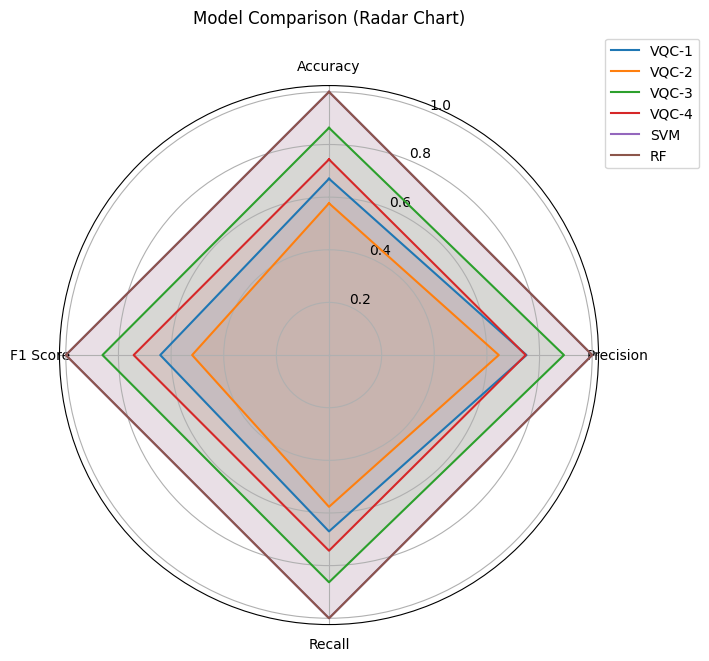

In [36]:

# Radar chart of all models
import matplotlib.pyplot as plt
import numpy as np

labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models = ['VQC-1', 'VQC-2', 'VQC-3', 'VQC-4', 'SVM', 'RF']
metrics = [
    [acc_1, prec_1, rec_1, f1_1], # Corrected variables for VQC-1
    [acc_2, prec_2, rec_2, f1_2],
    [acc_3, prec_3, rec_3, f1_3],
    [acc_4, prec_4, rec_4, f1_4],
    [acc_svm, prec_svm, rec_svm, f1_svm],
    [acc_rf, prec_rf, rec_rf, f1_rf],
]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for model, score in zip(models, metrics):
    data = score + score[:1]
    ax.plot(angles, data, label=model)
    ax.fill(angles, data, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Model Comparison (Radar Chart)", y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()
